In [2]:
!pip install open_clip_torch imagecorruptions torch torchvision matplotlib seaborn pandas numpy tqdm datasets Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00


In [ ]:
# !pip install "numpy<2"

In [ ]:
"""
===========================================================================
Robustness of VLM Encoders to Combined Image Corruptions:
An Empirical Study on Zero-Shot Classification
============================================================================
Requirements:
    pip install open_clip_torch imagecorruptions torch torchvision
    pip install matplotlib seaborn pandas numpy tqdm datasets Pillow
============================================================================
"""

import os
import json
import time
import warnings
from itertools import combinations
from typing import Dict, List, Tuple, Optional

# Monkey-patch для совместимости imagecorruptions с NumPy 2.0+
import numpy as np
if not hasattr(np, 'float_'):
    np.float_ = np.float64
if not hasattr(np, 'int_'):
    np.int_ = np.int64
if not hasattr(np, 'complex_'):
    np.complex_ = np.complex128
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm

import open_clip
from imagecorruptions import corrupt, get_corruption_names

warnings.filterwarnings("ignore")

# ============================================================================
# 0. КОНФИГУРАЦИЯ ЭКСПЕРИМЕНТА
# ============================================================================

CONFIG = {
    # ---------- Данные ----------
    # Путь к папке ImageNet val (структура: val/classname/img.JPEG)
    # Если None — скачаем через HuggingFace datasets
    "imagenet_val_path": None,
    "num_samples": 1000,            # Сколько изображений брать (для скорости)
    "seed": 42,

    # ---------- Коррупции ----------
    "corruptions": [
        "gaussian_noise",
        "motion_blur",
        "fog",
        "jpeg_compression",
        "brightness",
        "contrast",
        "shot_noise",
    ],
    "severities": [1, 3, 5],        # Уровни severity

    # ---------- Модели ----------
    "models": [
        ("ViT-B-32",   "laion2b_s34b_b79k"),
        ("ViT-B-16",   "laion2b_s34b_b88k"),
        ("ViT-L-14",   "laion2b_s32b_b82k"),
        # ("convnext_base_w", "laion2b_s13b_b82k"),  # раскомментируй если хочешь
    ],

    # ---------- Прочее ----------
    "batch_size": 64,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "output_dir": "results_combined_corruptions",
    "prompt_template": "a photo of a {}.",
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)


# ============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================================

class ImageNetSubset:
    """Загружает подмножество ImageNet-val."""

    # 1000 классов ImageNet — для zero-shot нужны текстовые метки
    # Загрузим из open_clip или из файла
    def __init__(self, config: dict):
        self.config = config
        self.images: List[Image.Image] = []
        self.labels: List[int] = []
        self.classnames: List[str] = []
        self._load()

    def _load(self):
        if self.config["imagenet_val_path"] and os.path.exists(self.config["imagenet_val_path"]):
            self._load_from_folder()
        else:
            self._load_from_huggingface()

    def _load_from_huggingface(self):
        """Загрузка через HuggingFace datasets."""
        print("📥 Загружаем ImageNet-1k из HuggingFace...")
        print("   (Нужен agreement на https://huggingface.co/datasets/ILSVRC/imagenet-1k)")
        try:
            from datasets import load_dataset
            ds = load_dataset(
                "ILSVRC/imagenet-1k",
                split="validation",

            )
        except Exception:
            print("⚠️  Не удалось загрузить ImageNet. Используем CIFAR-100 как fallback.")
            self._load_cifar100_fallback()
            return

        rng = np.random.RandomState(self.config["seed"])
        indices = rng.choice(len(ds), size=min(self.config["num_samples"], len(ds)), replace=False)

        self.classnames = ds.features["label"].names

        for idx in tqdm(indices, desc="Загрузка изображений"):
            item = ds[int(idx)]
            img = item["image"].convert("RGB")
            self.images.append(img)
            self.labels.append(item["label"])

        print(f"✅ Загружено {len(self.images)} изображений, {len(self.classnames)} классов")

    def _load_cifar100_fallback(self):
        """Fallback: CIFAR-100 (маленькие картинки, но для демо сойдёт)."""
        import torchvision.datasets as tvd

        print("📥 Загружаем CIFAR-100 как fallback...")
        ds = tvd.CIFAR100(root="./data", train=False, download=True)

        rng = np.random.RandomState(self.config["seed"])
        indices = rng.choice(len(ds), size=min(self.config["num_samples"], len(ds)), replace=False)

        # CIFAR-100 fine labels
        self.classnames = ds.classes

        for idx in indices:
            img, label = ds[int(idx)]
            if isinstance(img, np.ndarray):
                img = Image.fromarray(img)
            self.images.append(img.convert("RGB"))
            self.labels.append(label)

        print(f"✅ Загружено {len(self.images)} изображений, {len(self.classnames)} классов")

    def _load_from_folder(self):
        """Загрузка из локальной папки ImageNet val."""
        import torchvision.datasets as tvd

        print(f"📥 Загружаем ImageNet из {self.config['imagenet_val_path']}...")
        ds = tvd.ImageFolder(self.config["imagenet_val_path"])

        rng = np.random.RandomState(self.config["seed"])
        indices = rng.choice(len(ds), size=min(self.config["num_samples"], len(ds)), replace=False)

        # Загрузим classnames из папок
        self.classnames = ds.classes

        for idx in tqdm(indices, desc="Загрузка изображений"):
            img, label = ds[int(idx)]
            if isinstance(img, np.ndarray):
                img = Image.fromarray(img)
            self.images.append(img.convert("RGB"))
            self.labels.append(label)

        print(f"✅ Загружено {len(self.images)} изображений, {len(self.classnames)} классов")


# ============================================================================
# 2. ГЕНЕРАЦИЯ КОРРУПЦИЙ
# ============================================================================

class CorruptionGenerator:
    """Генерирует одиночные и комбинированные коррупции."""

    def __init__(self, corruption_types: List[str], severities: List[int]):
        self.corruption_types = corruption_types
        self.severities = severities

    def apply_single(self, img: Image.Image, corruption: str, severity: int) -> Image.Image:
        """Применяет одну коррупцию."""
        img_np = np.array(img)
        corrupted = corrupt(img_np, corruption_name=corruption, severity=severity)
        return Image.fromarray(corrupted)

    def apply_combined(
        self, img: Image.Image, c1: str, c2: str, severity: int
    ) -> Image.Image:
        """Применяет две коррупции последовательно: c1 → c2."""
        img_np = np.array(img)
        corrupted = corrupt(img_np, corruption_name=c1, severity=severity)
        corrupted = corrupt(corrupted, corruption_name=c2, severity=severity)
        return Image.fromarray(corrupted)

    def get_single_configs(self) -> List[Tuple[str, int]]:
        """Все (corruption, severity) пары."""
        return [(c, s) for c in self.corruption_types for s in self.severities]

    def get_combined_configs(self) -> List[Tuple[str, str, int]]:
        """Все (c1, c2, severity) тройки."""
        return [
            (c1, c2, s)
            for c1, c2 in combinations(self.corruption_types, 2)
            for s in self.severities
        ]


# ============================================================================
# 3. ZERO-SHOT КЛАССИФИКАТОР
# ============================================================================

class ZeroShotClassifier:
    """Обёртка над open_clip для zero-shot классификации."""

    def __init__(
        self,
        model_name: str,
        pretrained: str,
        classnames: List[str],
        prompt_template: str,
        device: str,
    ):
        self.device = device
        self.model_name = model_name

        print(f"🔧 Загружаем модель {model_name} ({pretrained})...")
        self.model, _, self.preprocess = open_clip.create_model_and_transforms(
            model_name, pretrained=pretrained
        )
        self.model = self.model.to(device).eval()
        self.tokenizer = open_clip.get_tokenizer(model_name)

        # Precompute text features для всех классов
        self.text_features = self._encode_classnames(classnames, prompt_template)
        print(f"✅ Модель {model_name} готова ({len(classnames)} классов)")

    @torch.no_grad()
    def _encode_classnames(self, classnames: List[str], template: str) -> torch.Tensor:
        """Кодирует текстовые описания классов."""
        texts = [template.format(c) for c in classnames]
        tokens = self.tokenizer(texts).to(self.device)
        text_features = self.model.encode_text(tokens)
        text_features = F.normalize(text_features, dim=-1)
        return text_features

    @torch.no_grad()
    def classify_batch(self, images: List[Image.Image]) -> np.ndarray:
        """Классифицирует батч PIL-изображений. Возвращает предсказанные метки."""
        tensors = torch.stack([self.preprocess(img) for img in images]).to(self.device)
        image_features = self.model.encode_image(tensors)
        image_features = F.normalize(image_features, dim=-1)

        # Cosine similarity → logits
        logits = image_features @ self.text_features.T
        preds = logits.argmax(dim=-1).cpu().numpy()
        return preds

    @torch.no_grad()
    def classify_batch_topk(
        self, images: List[Image.Image], k: int = 5
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Возвращает top-1 и top-k предсказания."""
        tensors = torch.stack([self.preprocess(img) for img in images]).to(self.device)
        image_features = self.model.encode_image(tensors)
        image_features = F.normalize(image_features, dim=-1)

        logits = image_features @ self.text_features.T
        top1 = logits.argmax(dim=-1).cpu().numpy()
        topk = logits.topk(k, dim=-1).indices.cpu().numpy()
        return top1, topk


# ============================================================================
# 4. EVALUATION ENGINE
# ============================================================================

class ExperimentRunner:
    """Основной движок эксперимента."""

    def __init__(self, config: dict):
        self.config = config
        self.results = {}  # {model_name: {corruption_key: {severity: {top1, top5}}}}

    def run(self):
        t_start = time.time()

        # --- Загружаем данные ---
        dataset = ImageNetSubset(self.config)
        images = dataset.images
        labels = np.array(dataset.labels)
        classnames = dataset.classnames

        # --- Инициализируем генератор коррупций ---
        corr_gen = CorruptionGenerator(
            self.config["corruptions"], self.config["severities"]
        )

        # --- Для каждой модели ---
        for model_name, pretrained in self.config["models"]:
            print(f"\n{'='*70}")
            print(f"  МОДЕЛЬ: {model_name}")
            print(f"{'='*70}")

            classifier = ZeroShotClassifier(
                model_name, pretrained, classnames,
                self.config["prompt_template"], self.config["device"],
            )

            model_results = {}

            # ---- 4a. Clean accuracy ----
            print("\n📊 Оцениваем CLEAN accuracy...")
            top1_acc, top5_acc = self._evaluate(classifier, images, labels)
            model_results["clean"] = {"top1": top1_acc, "top5": top5_acc}
            print(f"   Clean — Top-1: {top1_acc:.4f}, Top-5: {top5_acc:.4f}")

            # ---- 4b. Single corruptions ----
            print("\n📊 Оцениваем ОДИНОЧНЫЕ коррупции...")
            for corruption in self.config["corruptions"]:
                for severity in self.config["severities"]:
                    key = f"{corruption}"
                    if key not in model_results:
                        model_results[key] = {}

                    corrupted_images = []
                    for img in tqdm(
                        images,
                        desc=f"  {corruption} (s={severity})",
                        leave=False,
                    ):
                        corrupted_images.append(
                            corr_gen.apply_single(img, corruption, severity)
                        )

                    top1_acc, top5_acc = self._evaluate(classifier, corrupted_images, labels)
                    model_results[key][severity] = {"top1": top1_acc, "top5": top5_acc}
                    print(f"   {corruption} s={severity} — Top-1: {top1_acc:.4f}, Top-5: {top5_acc:.4f}")

            # ---- 4c. Combined corruptions ----
            print("\n📊 Оцениваем КОМБИНИРОВАННЫЕ коррупции...")
            for c1, c2 in combinations(self.config["corruptions"], 2):
                for severity in self.config["severities"]:
                    key = f"{c1}+{c2}"
                    if key not in model_results:
                        model_results[key] = {}

                    corrupted_images = []
                    for img in tqdm(
                        images,
                        desc=f"  {c1}+{c2} (s={severity})",
                        leave=False,
                    ):
                        corrupted_images.append(
                            corr_gen.apply_combined(img, c1, c2, severity)
                        )

                    top1_acc, top5_acc = self._evaluate(classifier, corrupted_images, labels)
                    model_results[key][severity] = {"top1": top1_acc, "top5": top5_acc}
                    print(f"   {c1}+{c2} s={severity} — Top-1: {top1_acc:.4f}, Top-5: {top5_acc:.4f}")

            self.results[model_name] = model_results

            # Освобождаем VRAM
            del classifier
            torch.cuda.empty_cache() if torch.cuda.is_available() else None

        elapsed = time.time() - t_start
        print(f"\n⏱️  Общее время: {elapsed / 60:.1f} мин")

        # --- Сохраняем ---
        self._save_results()
        return self.results

    def _evaluate(
        self,
        classifier: ZeroShotClassifier,
        images: List[Image.Image],
        labels: np.ndarray,
    ) -> Tuple[float, float]:
        """Оценивает top-1 и top-5 accuracy."""
        bs = self.config["batch_size"]
        all_top1 = []
        all_topk = []

        for i in range(0, len(images), bs):
            batch_imgs = images[i : i + bs]
            batch_labels = labels[i : i + bs]
            top1, topk = classifier.classify_batch_topk(batch_imgs, k=5)
            all_top1.append(top1 == batch_labels)
            all_topk.append(
                np.array([l in tk for l, tk in zip(batch_labels, topk)])
            )

        top1_acc = np.concatenate(all_top1).mean()
        top5_acc = np.concatenate(all_topk).mean()
        return float(top1_acc), float(top5_acc)

    def _save_results(self):
        path = os.path.join(self.config["output_dir"], "raw_results.json")
        with open(path, "w") as f:
            json.dump(self.results, f, indent=2)
        print(f"💾 Результаты сохранены в {path}")


# ============================================================================
# 5. АНАЛИЗ И ВИЗУАЛИЗАЦИЯ
# ============================================================================

class ResultsAnalyzer:
    """Анализирует результаты и строит графики."""

    def __init__(self, results: dict, config: dict):
        self.results = results
        self.config = config
        self.output_dir = config["output_dir"]
        self.corruptions = config["corruptions"]

    def run_full_analysis(self):
        """Запускает весь анализ."""
        self.plot_degradation_heatmaps()
        self.plot_superadditivity_analysis()
        self.plot_severity_curves()
        self.generate_summary_table()
        print(f"\n📊 Все графики сохранены в '{self.output_dir}/'")

    # ----- 5a. Heatmap деградации: corruption × corruption -----
    def plot_degradation_heatmaps(self):
        """Для каждой модели строит heatmap accuracy drop по парам коррупций."""
        for model_name, model_res in self.results.items():
            for severity in self.config["severities"]:
                n = len(self.corruptions)
                matrix = np.zeros((n, n))

                clean_top1 = model_res["clean"]["top1"]

                for i, c1 in enumerate(self.corruptions):
                    # Диагональ — одиночная коррупция
                    if c1 in model_res and severity in model_res[c1]:
                        matrix[i][i] = clean_top1 - model_res[c1][severity]["top1"]

                    for j, c2 in enumerate(self.corruptions):
                        if i >= j:
                            continue
                        key = f"{c1}+{c2}"
                        if key not in model_res:
                            key = f"{c2}+{c1}"
                        if key in model_res and severity in model_res[key]:
                            drop = clean_top1 - model_res[key][severity]["top1"]
                            matrix[i][j] = drop
                            matrix[j][i] = drop

                # Построение
                fig, ax = plt.subplots(figsize=(10, 8))
                short_names = [c.replace("_", "\n") for c in self.corruptions]
                sns.heatmap(
                    matrix,
                    xticklabels=short_names,
                    yticklabels=short_names,
                    annot=True,
                    fmt=".3f",
                    cmap="YlOrRd",
                    ax=ax,
                    vmin=0,
                    square=True,
                )
                ax.set_title(
                    f"Accuracy Drop (Top-1) — {model_name}, severity={severity}\n"
                    f"(Diagonal = single corruption, Off-diagonal = combined)",
                    fontsize=12,
                )
                plt.tight_layout()
                fname = f"heatmap_{model_name}_s{severity}.png"
                plt.savefig(os.path.join(self.output_dir, fname), dpi=150)
                plt.close()
                print(f"   📈 Saved {fname}")

    # ----- 5b. Анализ супераддитивности -----
    def plot_superadditivity_analysis(self):
        """
        Для каждой пары (c1, c2) считаем:
            interaction = drop(c1+c2) - (drop(c1) + drop(c2))
        Если interaction > 0 → суперадддитивность (комбинация хуже суммы).
        Если interaction < 0 → субаддитивность.
        """
        records = []

        for model_name, model_res in self.results.items():
            clean_top1 = model_res["clean"]["top1"]

            for severity in self.config["severities"]:
                for c1, c2 in combinations(self.corruptions, 2):
                    key_combined = f"{c1}+{c2}"
                    if key_combined not in model_res:
                        key_combined = f"{c2}+{c1}"

                    if (
                        key_combined in model_res
                        and severity in model_res[key_combined]
                        and c1 in model_res
                        and severity in model_res[c1]
                        and c2 in model_res
                        and severity in model_res[c2]
                    ):
                        drop_c1 = clean_top1 - model_res[c1][severity]["top1"]
                        drop_c2 = clean_top1 - model_res[c2][severity]["top1"]
                        drop_combined = clean_top1 - model_res[key_combined][severity]["top1"]

                        interaction = drop_combined - (drop_c1 + drop_c2)

                        records.append({
                            "model": model_name,
                            "c1": c1,
                            "c2": c2,
                            "severity": severity,
                            "drop_c1": drop_c1,
                            "drop_c2": drop_c2,
                            "drop_combined": drop_combined,
                            "expected_additive": drop_c1 + drop_c2,
                            "interaction": interaction,
                            "interaction_type": (
                                "superadditive" if interaction > 0.005
                                else ("subadditive" if interaction < -0.005 else "additive")
                            ),
                        })

        df = pd.DataFrame(records)
        df.to_csv(os.path.join(self.output_dir, "superadditivity_analysis.csv"), index=False)

        # --- Бар-плот interaction effects ---
        if len(df) == 0:
            print("   ⚠️  Нет данных для анализа суперадддитивности")
            return

        for model_name in df["model"].unique():
            mdf = df[df["model"] == model_name]

            fig, axes = plt.subplots(1, len(self.config["severities"]),
                                     figsize=(6 * len(self.config["severities"]), 8))
            if len(self.config["severities"]) == 1:
                axes = [axes]

            for ax, severity in zip(axes, self.config["severities"]):
                sdf = mdf[mdf["severity"] == severity].sort_values("interaction", ascending=True)
                pair_labels = [f"{r['c1'][:6]}+\n{r['c2'][:6]}" for _, r in sdf.iterrows()]
                colors = [
                    "#d32f2f" if v > 0.005 else ("#1976d2" if v < -0.005 else "#757575")
                    for v in sdf["interaction"]
                ]
                ax.barh(pair_labels, sdf["interaction"], color=colors)
                ax.axvline(0, color="black", linewidth=0.8)
                ax.set_xlabel("Interaction Effect (Δ accuracy drop)")
                ax.set_title(f"Severity = {severity}")
                ax.tick_params(axis="y", labelsize=8)

            fig.suptitle(
                f"Superadditivity Analysis — {model_name}\n"
                f"(Red = superadditive, Blue = subadditive, Grey = additive)",
                fontsize=13,
            )
            plt.tight_layout()
            fname = f"superadditivity_{model_name}.png"
            plt.savefig(os.path.join(self.output_dir, fname), dpi=150)
            plt.close()
            print(f"   📈 Saved {fname}")

        # --- Сводная статистика ---
        print("\n" + "=" * 60)
        print("  SUPERADDITIVITY SUMMARY")
        print("=" * 60)
        summary = df.groupby(["model", "severity", "interaction_type"]).size().unstack(fill_value=0)
        print(summary.to_string())
        print()

        # Топ-5 суперадддитивных пар
        top_super = df.nlargest(5, "interaction")
        print("🔴 TOP-5 Superadditive pairs (most dangerous combinations):")
        for _, r in top_super.iterrows():
            print(
                f"   {r['model']} | {r['c1']}+{r['c2']} s={r['severity']} | "
                f"interaction={r['interaction']:+.4f} "
                f"(combined drop={r['drop_combined']:.4f} vs expected={r['expected_additive']:.4f})"
            )

    # ----- 5c. Кривые деградации по severity -----
    def plot_severity_curves(self):
        """Для каждой модели: кривые accuracy по severity для clean/single/combined."""
        for model_name, model_res in self.results.items():
            clean_top1 = model_res["clean"]["top1"]

            fig, ax = plt.subplots(figsize=(12, 7))

            # Средняя деградация одиночных
            single_means = []
            for s in self.config["severities"]:
                accs = []
                for c in self.corruptions:
                    if c in model_res and s in model_res[c]:
                        accs.append(model_res[c][s]["top1"])
                single_means.append(np.mean(accs) if accs else clean_top1)

            # Средняя деградация комбинированных
            combined_means = []
            for s in self.config["severities"]:
                accs = []
                for c1, c2 in combinations(self.corruptions, 2):
                    key = f"{c1}+{c2}"
                    if key not in model_res:
                        key = f"{c2}+{c1}"
                    if key in model_res and s in model_res[key]:
                        accs.append(model_res[key][s]["top1"])
                combined_means.append(np.mean(accs) if accs else clean_top1)

            severities = self.config["severities"]
            ax.plot(
                [0] + severities,
                [clean_top1] + single_means,
                "o-", linewidth=2, markersize=8, label="Avg Single Corruption", color="#1976d2",
            )
            ax.plot(
                [0] + severities,
                [clean_top1] + combined_means,
                "s--", linewidth=2, markersize=8, label="Avg Combined Corruption", color="#d32f2f",
            )
            ax.axhline(clean_top1, linestyle=":", color="green", alpha=0.7, label=f"Clean ({clean_top1:.3f})")

            ax.set_xlabel("Severity", fontsize=13)
            ax.set_ylabel("Top-1 Accuracy", fontsize=13)
            ax.set_title(f"Degradation Curves — {model_name}", fontsize=14)
            ax.legend(fontsize=11)
            ax.grid(True, alpha=0.3)
            ax.set_xticks([0] + severities)
            ax.set_xticklabels(["clean"] + [str(s) for s in severities])

            plt.tight_layout()
            fname = f"severity_curves_{model_name}.png"
            plt.savefig(os.path.join(self.output_dir, fname), dpi=150)
            plt.close()
            print(f"   📈 Saved {fname}")

    # ----- 5d. Сводная таблица -----
    def generate_summary_table(self):
        """Генерирует LaTeX-ready сводную таблицу."""
        rows = []

        for model_name, model_res in self.results.items():
            clean = model_res["clean"]["top1"]
            row = {"Model": model_name, "Clean Top-1": f"{clean:.4f}"}

            for severity in self.config["severities"]:
                # Средняя acc одиночных
                single_accs = []
                for c in self.corruptions:
                    if c in model_res and severity in model_res[c]:
                        single_accs.append(model_res[c][severity]["top1"])
                avg_single = np.mean(single_accs) if single_accs else 0

                # Средняя acc комбинированных
                combined_accs = []
                for c1, c2 in combinations(self.corruptions, 2):
                    key = f"{c1}+{c2}"
                    if key not in model_res:
                        key = f"{c2}+{c1}"
                    if key in model_res and severity in model_res[key]:
                        combined_accs.append(model_res[key][severity]["top1"])
                avg_combined = np.mean(combined_accs) if combined_accs else 0

                row[f"Single s={severity}"] = f"{avg_single:.4f}"
                row[f"Combined s={severity}"] = f"{avg_combined:.4f}"
                row[f"Gap s={severity}"] = f"{avg_single - avg_combined:.4f}"

            rows.append(row)

        df = pd.DataFrame(rows)
        print("\n" + "=" * 80)
        print("  SUMMARY TABLE")
        print("=" * 80)
        print(df.to_string(index=False))

        # Сохраняем
        df.to_csv(os.path.join(self.output_dir, "summary_table.csv"), index=False)

        # LaTeX
        latex_path = os.path.join(self.output_dir, "summary_table.tex")
        with open(latex_path, "w") as f:
            f.write(df.to_latex(index=False, float_format="%.4f"))
        print(f"💾 LaTeX таблица сохранена в {latex_path}")


# ============================================================================
# 6. БОНУС: Визуальные примеры коррупций
# ============================================================================

def plot_corruption_examples(dataset: ImageNetSubset, config: dict):
    """Рисует пример одного изображения под всеми коррупциями."""
    corr_gen = CorruptionGenerator(config["corruptions"], config["severities"])

    # Берём первое изображение
    img = dataset.images[0]
    severity = 3

    n_corr = len(config["corruptions"])
    n_pairs = len(list(combinations(config["corruptions"], 2)))

    fig, axes = plt.subplots(3, max(n_corr, 7), figsize=(24, 10))
    for ax_row in axes:
        for ax in ax_row:
            ax.axis("off")

    # Row 0: Clean
    axes[0][0].imshow(img)
    axes[0][0].set_title("Clean", fontsize=10, fontweight="bold")

    # Row 1: Single corruptions
    for i, c in enumerate(config["corruptions"]):
        corrupted = corr_gen.apply_single(img, c, severity)
        axes[1][i].imshow(corrupted)
        axes[1][i].set_title(c.replace("_", "\n"), fontsize=8)

    # Row 2: Some combined corruptions
    pairs = list(combinations(config["corruptions"], 2))[:len(axes[2])]
    for i, (c1, c2) in enumerate(pairs):
        corrupted = corr_gen.apply_combined(img, c1, c2, severity)
        axes[2][i].imshow(corrupted)
        axes[2][i].set_title(f"{c1[:8]}+\n{c2[:8]}", fontsize=7)

    axes[0][0].set_ylabel("Clean", fontsize=12, rotation=0, labelpad=50)
    axes[1][0].set_ylabel("Single", fontsize=12, rotation=0, labelpad=50)
    axes[2][0].set_ylabel("Combined", fontsize=12, rotation=0, labelpad=50)

    fig.suptitle(f"Corruption Examples (severity={severity})", fontsize=14)
    plt.tight_layout()
    fname = os.path.join(config["output_dir"], "corruption_examples.png")
    plt.savefig(fname, dpi=150)
    plt.close()
    print(f"   📈 Saved corruption_examples.png")


# ============================================================================
# 7. MAIN
# ============================================================================

def main():
    print("=" * 70)
    print("  ROBUSTNESS OF VLM ENCODERS TO COMBINED IMAGE CORRUPTIONS")
    print("  An Empirical Study on Zero-Shot Classification")
    print("=" * 70)
    print(f"\n⚙️  Device: {CONFIG['device']}")
    print(f"⚙️  Models: {[m[0] for m in CONFIG['models']]}")
    print(f"⚙️  Corruptions: {CONFIG['corruptions']}")
    print(f"⚙️  Severities: {CONFIG['severities']}")
    print(f"⚙️  Samples: {CONFIG['num_samples']}")
    print()

    # --- Запускаем эксперимент ---
    runner = ExperimentRunner(CONFIG)
    results = runner.run()

    # --- Анализ и визуализация ---
    print("\n" + "=" * 70)
    print("  АНАЛИЗ РЕЗУЛЬТАТОВ")
    print("=" * 70)
    analyzer = ResultsAnalyzer(results, CONFIG)
    analyzer.run_full_analysis()

    # --- Примеры коррупций ---
    print("\n🎨 Генерируем визуальные примеры коррупций...")
    dataset = ImageNetSubset(CONFIG)
    plot_corruption_examples(dataset, CONFIG)

    print("\n✅ ГОТОВО! Все результаты в папке:", CONFIG["output_dir"])
    print("   📄 raw_results.json — сырые результаты")
    print("   📄 superadditivity_analysis.csv — анализ interaction effects")
    print("   📄 summary_table.csv / .tex — сводная таблица")
    print("   📊 heatmap_*.png — тепловые карты деградации")
    print("   📊 superadditivity_*.png — анализ суперадддитивности")
    print("   📊 severity_curves_*.png — кривые деградации")
    print("   📊 corruption_examples.png — визуальные примеры")


if __name__ == "__main__":
    main()

  ROBUSTNESS OF VLM ENCODERS TO COMBINED IMAGE CORRUPTIONS
  An Empirical Study on Zero-Shot Classification

⚙️  Device: cuda
⚙️  Models: ['ViT-B-32', 'ViT-B-16', 'ViT-L-14']
⚙️  Corruptions: ['gaussian_noise', 'motion_blur', 'fog', 'jpeg_compression', 'brightness', 'contrast', 'shot_noise']
⚙️  Severities: [1, 3, 5]
⚙️  Samples: 1000

📥 Загружаем ImageNet-1k из HuggingFace...
   (Нужен agreement на https://huggingface.co/datasets/ILSVRC/imagenet-1k)
⚠️  Не удалось загрузить ImageNet. Используем CIFAR-100 как fallback.
📥 Загружаем CIFAR-100 как fallback...
✅ Загружено 1000 изображений, 100 классов

  МОДЕЛЬ: ViT-B-32
🔧 Загружаем модель ViT-B-32 (laion2b_s34b_b79k)...
✅ Модель ViT-B-32 готова (100 классов)

📊 Оцениваем CLEAN accuracy...
   Clean — Top-1: 0.7530, Top-5: 0.9340

📊 Оцениваем ОДИНОЧНЫЕ коррупции...


   gaussian_noise s=1 — Top-1: 0.2760, Top-5: 0.4980


   gaussian_noise s=3 — Top-1: 0.0640, Top-5: 0.1720


   gaussian_noise s=5 — Top-1: 0.0170, Top-5: 0.0700


   motion_blur s=1 — Top-1: 0.4230, Top-5: 0.6840


...

   brightness+shot_noise s=3 — Top-1: 0.0870, Top-5: 0.2310


   brightness+shot_noise s=5 — Top-1: 0.0220, Top-5: 0.0690


   contrast+shot_noise s=1 — Top-1: 0.0650, Top-5: 0.1800


   contrast+shot_noise s=3 — Top-1: 0.0170, Top-5: 0.0620


   contrast+shot_noise s=5 — Top-1: 0.0160, Top-5: 0.0580

⏱️  Общее время: 111.0 мин
💾 Результаты сохранены в results_combined_corruptions/raw_results.json

  АНАЛИЗ РЕЗУЛЬТАТОВ
   📈 Saved heatmap_ViT-B-32_s1.png
   📈 Saved heatmap_ViT-B-32_s3.png
   📈 Saved heatmap_ViT-B-32_s5.png
   📈 Saved heatmap_ViT-B-16_s1.png
   📈 Saved heatmap_ViT-B-16_s3.png
   📈 Saved heatmap_ViT-B-16_s5.png
   📈 Saved heatmap_ViT-L-14_s1.png
   📈 Saved heatmap_ViT-L-14_s3.png
   📈 Saved heatmap_ViT-L-14_s5.png
   📈 Saved superadditivity_ViT-B-32.png
   📈 Saved superadditivity_ViT-B-16.png
   📈 Saved superadditivity_ViT-L-14.png

  SUPERADDITIVITY SUMMARY
interaction_type   additive  subadditive  superadditive
model    severity                                      
ViT-B-16 1                0           15              6
         3                0           21              0
         5                0           21              0
ViT-B-32 1                3           10              8
         3             

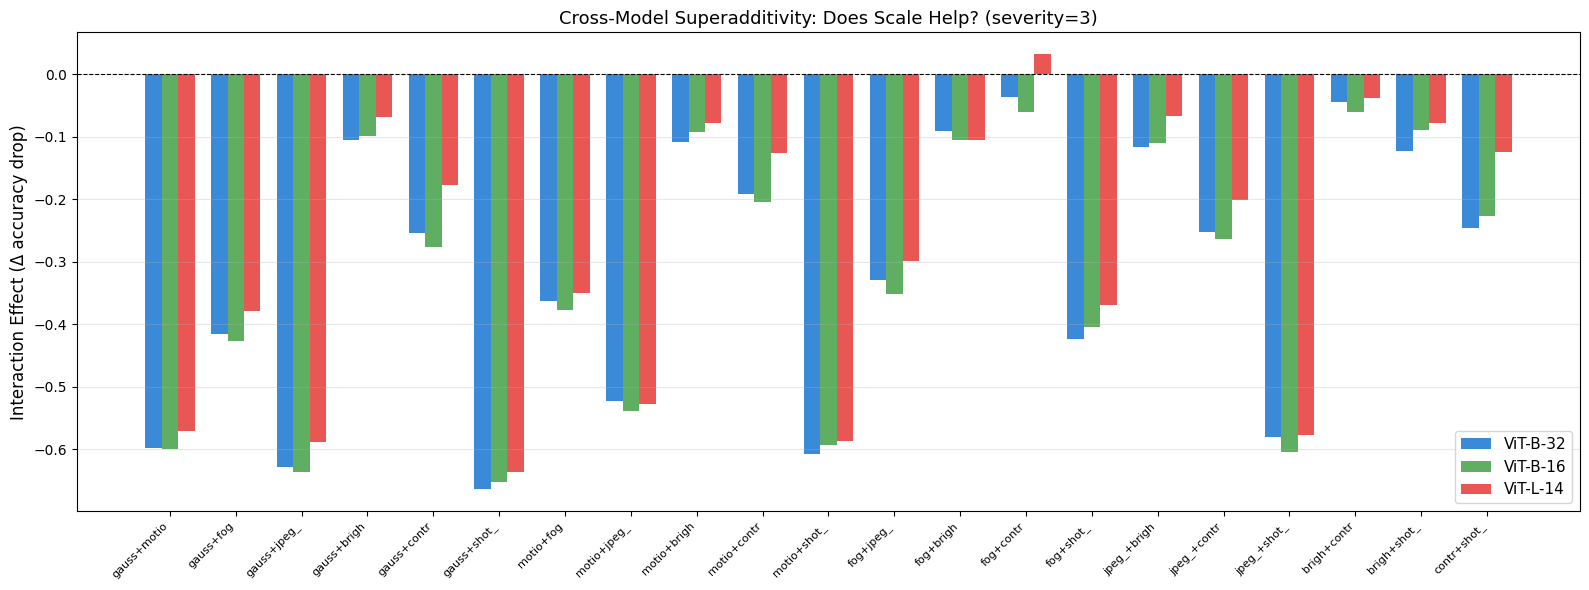

✅ Saved!


In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# Загружаем результаты
with open("raw_results.json") as f:
    results = json.load(f)

corruptions = [
    'gaussian_noise', 'motion_blur', 'fog',
    'jpeg_compression', 'brightness', 'contrast', 'shot_noise'
]
models_order = ['ViT-B-32', 'ViT-B-16', 'ViT-L-14']
severity = 3  # фиксируем средний

records = []
for model_name, model_res in results.items():
    clean = model_res["clean"]["top1"]
    for c1, c2 in combinations(corruptions, 2):
        key = f"{c1}+{c2}"
        if key not in model_res:
            key = f"{c2}+{c1}"
        if (key in model_res and str(severity) in model_res[key]
            and c1 in model_res and str(severity) in model_res[c1]
            and c2 in model_res and str(severity) in model_res[c2]):

            drop_c1 = clean - model_res[c1][str(severity)]["top1"]
            drop_c2 = clean - model_res[c2][str(severity)]["top1"]
            drop_comb = clean - model_res[key][str(severity)]["top1"]
            interaction = drop_comb - (drop_c1 + drop_c2)

            records.append({
                "model": model_name,
                "pair": f"{c1[:5]}+{c2[:5]}",
                "interaction": interaction
            })

df = pd.DataFrame(records)

# Строим grouped bar chart
pairs = df["pair"].unique()
x = np.arange(len(pairs))
width = 0.25
colors = ["#1976d2", "#43a047", "#e53935"]

fig, ax = plt.subplots(figsize=(16, 6))
for i, model in enumerate(models_order):
    mdf = df[df["model"] == model].set_index("pair")
    values = [mdf.loc[p, "interaction"] if p in mdf.index else 0 for p in pairs]
    ax.bar(x + i * width, values, width, label=model, color=colors[i], alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x + width)
ax.set_xticklabels(pairs, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Interaction Effect (Δ accuracy drop)", fontsize=12)
ax.set_title("Cross-Model Superadditivity: Does Scale Help? (severity=3)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("cross_model_superadditivity.png", dpi=150)
plt.show()
print("✅ Saved!")

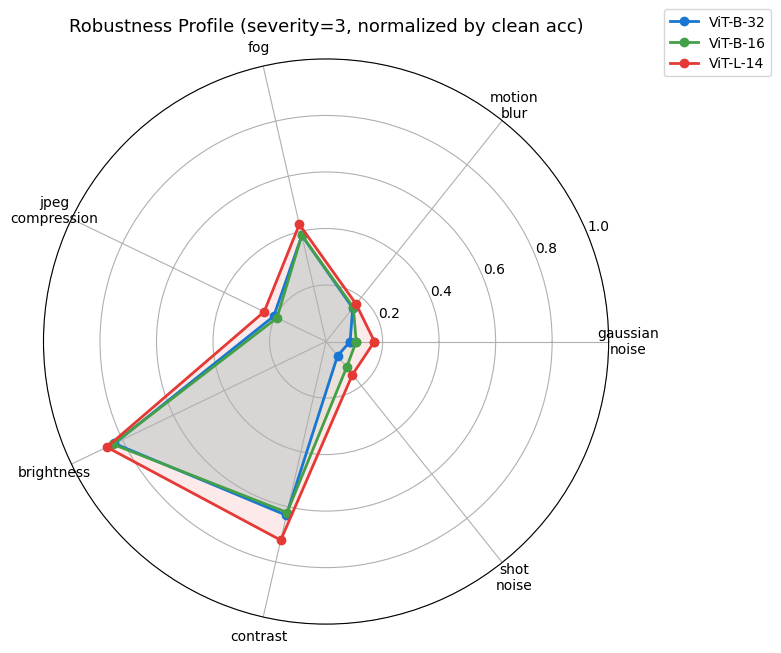

✅ Saved!


In [ ]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = corruptions
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ["#1976d2", "#43a047", "#e53935"]

for color, (model_name, model_res) in zip(colors, results.items()):
    clean = model_res["clean"]["top1"]
    values = []
    for c in categories:
        if c in model_res and 3 in model_res[c]:
            # Нормализуем: 1.0 = clean accuracy, 0.0 = полная деградация
            values.append(model_res[c][3]["top1"] / clean)
        elif c in model_res and "3" in model_res[c]:
            values.append(model_res[c]["3"]["top1"] / clean)
        else:
            values.append(0)
    values += values[:1]

    ax.plot(angles, values, "o-", linewidth=2, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.replace("_", "\n") for c in categories], fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("Robustness Profile (severity=3, normalized by clean acc)",
             fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig("results_combined_corruptions/radar_robustness.png", dpi=150)
plt.show()
print("✅ Saved!")

In [ ]:
# mCE = mean Corruption Error, стандартная метрика из ImageNet-C
# CE_c = (1/5) * sum_s [error_s / alexnet_error_s]
# Но у нас нет AlexNet baseline → считаем relative mCE к clean

records_mce = []
for model_name, model_res in results.items():
    clean_err = 1 - model_res["clean"]["top1"]

    # Single corruptions mCE
    single_ces = []
    for c in corruptions:
        if c in model_res:
            ces = []
            for s in [1, 3, 5]:
                key = str(s) if str(s) in model_res[c] else s
                if key in model_res[c]:
                    err = 1 - model_res[c][key]["top1"]
                    ces.append(err / clean_err)
            if ces:
                single_ces.append(np.mean(ces))

    # Combined corruptions mCE
    combined_ces = []
    for c1, c2 in combinations(corruptions, 2):
        key_pair = f"{c1}+{c2}"
        if key_pair not in model_res:
            key_pair = f"{c2}+{c1}"
        if key_pair in model_res:
            ces = []
            for s in [1, 3, 5]:
                key_s = str(s) if str(s) in model_res[key_pair] else s
                if key_s in model_res[key_pair]:
                    err = 1 - model_res[key_pair][key_s]["top1"]
                    ces.append(err / clean_err)
            if ces:
                combined_ces.append(np.mean(ces))

    records_mce.append({
        "Model": model_name,
        "Clean Acc": f"{model_res['clean']['top1']:.4f}",
        "mCE (single)": f"{np.mean(single_ces):.4f}" if single_ces else "—",
        "mCE (combined)": f"{np.mean(combined_ces):.4f}" if combined_ces else "—",
        "Δ mCE": f"{np.mean(combined_ces) - np.mean(single_ces):+.4f}" if (single_ces and combined_ces) else "—"
    })

df_mce = pd.DataFrame(records_mce)
print("\n=== mCE TABLE (для статьи) ===")
print(df_mce.to_string(index=False))
print()
print("=== LaTeX ===")
print(df_mce.to_latex(index=False))


=== mCE TABLE (для статьи) ===
   Model Clean Acc mCE (single) mCE (combined)   Δ mCE
ViT-B-32    0.7530       2.9350         3.6214 +0.6863
ViT-B-16    0.7880       3.3533         4.1753 +0.8220
ViT-L-14    0.8350       3.9977         5.1910 +1.1933

=== LaTeX ===
\begin{tabular}{lllll}
\toprule
Model & Clean Acc & mCE (single) & mCE (combined) & Δ mCE \\
\midrule
ViT-B-32 & 0.7530 & 2.9350 & 3.6214 & +0.6863 \\
ViT-B-16 & 0.7880 & 3.3533 & 4.1753 & +0.8220 \\
ViT-L-14 & 0.8350 & 3.9977 & 5.1910 & +1.1933 \\
\bottomrule
\end{tabular}



In [6]:
"""
Ablation: Order Sensitivity
Проверяем c1->c2 vs c2->c1 для топ-5 суперадддитивных пар
Результат: заполненная Table 4 для статьи
"""

# ============================================================================
# ПАТЧИ (первыми!)
# ============================================================================
import numpy as np
if not hasattr(np, 'float_'):    np.float_ = np.float64
if not hasattr(np, 'int_'):      np.int_ = np.int64
if not hasattr(np, 'complex_'):  np.complex_ = np.complex128

import torch
import torch.nn.functional as F
from PIL import Image
from imagecorruptions import corrupt
import open_clip
import torchvision.datasets as tvd
import pandas as pd

# ============================================================================
# КОНФИГ
# ============================================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 42
N      = 1000

# Топ-5 суперадддитивных пар из наших результатов
TOP5_PAIRS = [
    ("contrast",    "shot_noise"),   # I=+0.227 (L-14), самая опасная
    ("fog",         "shot_noise"),   # I=+0.110 (L-14)
    ("fog",         "contrast"),     # I=+0.089 (B-32)
    ("motion_blur", "fog"),          # I=+0.075 (B-32)
    ("motion_blur", "contrast"),     # I=+0.058 (B-32)
]

SEVERITY = 1  # Тестируем при s=1 (там суперадддитивность максимальна)

# Только одна модель для абляции (ViT-B-32 — самая быстрая)
MODEL_NAME  = "ViT-B-32"
PRETRAINED  = "laion2b_s34b_b79k"
PROMPT      = "a photo of a {}."
BATCH_SIZE  = 64

# ============================================================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================================================
print("📥 Загружаем CIFAR-100...")
rng = np.random.RandomState(SEED)
ds  = tvd.CIFAR100(root="./data", train=False, download=True)
idx = rng.choice(len(ds), size=N, replace=False)

images     = []
labels     = []
classnames = ds.classes

for i in idx:
    img, label = ds[int(i)]
    if isinstance(img, np.ndarray):
        img = Image.fromarray(img)
    images.append(img.convert("RGB"))
    labels.append(label)

labels = np.array(labels)
print(f"✅ Загружено {len(images)} изображений, {len(classnames)} классов")

# ============================================================================
# 2. ЗАГРУЗКА МОДЕЛИ
# ============================================================================
print(f"\n🔧 Загружаем {MODEL_NAME}...")
model, _, preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME, pretrained=PRETRAINED
)
model = model.to(DEVICE).eval()
tokenizer = open_clip.get_tokenizer(MODEL_NAME)

# Precompute text features
texts = [PROMPT.format(c) for c in classnames]
with torch.no_grad():
    tokens = tokenizer(texts).to(DEVICE)
    text_features = model.encode_text(tokens)
    text_features = F.normalize(text_features, dim=-1)
print(f"✅ Модель готова")

# ============================================================================
# 3. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================================

def apply_corruptions(imgs, c1, c2, severity):
    """Применяет c1 → c2."""
    result = []
    for img in imgs:
        arr = np.array(img)
        arr = corrupt(arr, corruption_name=c1, severity=severity)
        arr = corrupt(arr, corruption_name=c2, severity=severity)
        result.append(Image.fromarray(arr))
    return result

@torch.no_grad()
def evaluate(imgs, lbls):
    """Считает Top-1 accuracy."""
    correct = 0
    for i in range(0, len(imgs), BATCH_SIZE):
        batch = imgs[i:i+BATCH_SIZE]
        batch_lbls = lbls[i:i+BATCH_SIZE]
        tensors = torch.stack([preprocess(img) for img in batch]).to(DEVICE)
        feats   = F.normalize(model.encode_image(tensors), dim=-1)
        logits  = feats @ text_features.T
        preds   = logits.argmax(dim=-1).cpu().numpy()
        correct += (preds == batch_lbls).sum()
    return correct / len(imgs)

# ============================================================================
# 4. CLEAN ACCURACY
# ============================================================================
print("\n📊 Clean accuracy...")
clean_acc = evaluate(images, labels)
print(f"   Clean Top-1: {clean_acc:.4f}")

# ============================================================================
# 5. SINGLE CORRUPTIONS (нужны для interaction effect)
# ============================================================================
print("\n📊 Single corruptions...")
single_acc = {}
all_corruptions = list(set([c for pair in TOP5_PAIRS for c in pair]))

for c in all_corruptions:
    corrupted = apply_corruptions(images, c, c, SEVERITY)  # применяем одну
    # Но для single надо применить одну — переделаем чуть иначе
    single_corrupted = []
    for img in images:
        arr = np.array(img)
        arr = corrupt(arr, corruption_name=c, severity=SEVERITY)
        single_corrupted.append(Image.fromarray(arr))
    single_acc[c] = evaluate(single_corrupted, labels)
    print(f"   {c} → {single_acc[c]:.4f}")

# ============================================================================
# 6. ABLATION: c1→c2 vs c2→c1
# ============================================================================
print(f"\n📊 Ablation: order sensitivity (severity={SEVERITY})...")
print("="*70)

rows = []
for c1, c2 in TOP5_PAIRS:
    # Порядок 1: c1 → c2
    imgs_forward  = apply_corruptions(images, c1, c2, SEVERITY)
    acc_forward   = evaluate(imgs_forward, labels)

    # Порядок 2: c2 → c1
    imgs_backward = apply_corruptions(images, c2, c1, SEVERITY)
    acc_backward  = evaluate(imgs_backward, labels)

    # Interaction effects
    drop_c1       = clean_acc - single_acc[c1]
    drop_c2       = clean_acc - single_acc[c2]
    expected_drop = drop_c1 + drop_c2

    drop_forward  = clean_acc - acc_forward
    drop_backward = clean_acc - acc_backward
    I_forward     = drop_forward  - expected_drop
    I_backward    = drop_backward - expected_drop
    delta         = abs(acc_forward - acc_backward)

    rows.append({
        "Pair":          f"{c1} + {c2}",
        "c1→c2 acc":     f"{acc_forward:.4f}",
        "c2→c1 acc":     f"{acc_backward:.4f}",
        "Δ (order)":     f"{delta:.4f}",
        "I (c1→c2)":     f"{I_forward:+.4f}",
        "I (c2→c1)":     f"{I_backward:+.4f}",
        "Order-invariant": "✅" if delta < 0.01 else "⚠️",
    })

    print(f"\n  {c1} + {c2}:")
    print(f"    c1→c2:  acc={acc_forward:.4f},  I={I_forward:+.4f}")
    print(f"    c2→c1:  acc={acc_backward:.4f}, I={I_backward:+.4f}")
    print(f"    Δ(order) = {delta:.4f}  →  {'✅ order-invariant' if delta < 0.01 else '⚠️  order-sensitive!'}")

# ============================================================================
# 7. ИТОГОВАЯ ТАБЛИЦА
# ============================================================================
df = pd.DataFrame(rows)
print("\n" + "="*70)
print("  TABLE 4: ABLATION STUDY — ORDER SENSITIVITY")
print("="*70)
print(df.to_string(index=False))

# Сохраняем
df.to_csv("ablation_order.csv", index=False)

# LaTeX
latex = df[["Pair", "c1→c2 acc", "c2→c1 acc", "Δ (order)", "I (c1→c2)", "I (c2→c1)"]].to_latex(
    index=False,
    caption="Ablation study: effect of corruption application order ($c_1 \\to c_2$ vs.\\ $c_2 \\to c_1$) for top superadditive pairs on ViT-B/32, severity $s=1$.",
    label="tab:ablation",
    escape=False
)
with open("ablation_order.tex", "w") as f:
    f.write(latex)

print("\n💾 Сохранено:")
print("   ablation_order.csv")
print("   ablation_order.tex")
print("\n✅ ГОТОВО — вставляй ablation_order.tex прямо в статью!")

📥 Загружаем CIFAR-100...


100%|██████████| 169M/169M [08:20<00:00, 338kB/s]


✅ Загружено 1000 изображений, 100 классов

🔧 Загружаем ViT-B-32...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

✅ Модель готова

📊 Clean accuracy...
   Clean Top-1: 0.7530

📊 Single corruptions...
   motion_blur → 0.4270
   contrast → 0.6480
   fog → 0.5130
   shot_noise → 0.2510

📊 Ablation: order sensitivity (severity=1)...

  contrast + shot_noise:
    c1→c2:  acc=0.0390,  I=+0.1070
    c2→c1:  acc=0.2140, I=-0.0680
    Δ(order) = 0.1750  →  ⚠️  order-sensitive!

  fog + shot_noise:
    c1→c2:  acc=0.0210,  I=-0.0100
    c2→c1:  acc=0.1260, I=-0.1150
    Δ(order) = 0.1050  →  ⚠️  order-sensitive!

  fog + contrast:
    c1→c2:  acc=0.3560,  I=+0.0520
    c2→c1:  acc=0.1460, I=+0.2620
    Δ(order) = 0.2100  →  ⚠️  order-sensitive!

  motion_blur + fog:
    c1→c2:  acc=0.1220,  I=+0.0650
    c2→c1:  acc=0.1730, I=+0.0140
    Δ(order) = 0.0510  →  ⚠️  order-sensitive!

  motion_blur + contrast:
    c1→c2:  acc=0.2590,  I=+0.0630
    c2→c1:  acc=0.2660, I=+0.0560
    Δ(order) = 0.0070  →  ✅ order-invariant

  TABLE 4: ABLATION STUDY — ORDER SENSITIVITY
                  Pair c1→c2 acc c2→c1 acc Δ 

In [9]:
"""
Перегенерация corruption_examples.png — крупные картинки, минимум пространства
"""
import numpy as np
if not hasattr(np, 'float_'):    np.float_ = np.float64
if not hasattr(np, 'int_'):      np.int_ = np.int64

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from imagecorruptions import corrupt
import torchvision.datasets as tvd
import os

# ============================================================================
# КОНФИГ
# ============================================================================
SEED       = 42
SEVERITY   = 3
OUTPUT_DIR = "results_combined_corruptions"
IMG_SIZE   = 256   # ← большой размер (было 128)
FONT_SIZE  = 20

CORRUPTIONS_SINGLE = [
    "gaussian_noise", "motion_blur", "fog",
    "jpeg_compression", "brightness", "contrast", "shot_noise",
]
CORRUPTIONS_COMBINED = [
    ("contrast",      "shot_noise"),
    ("fog",           "shot_noise"),
    ("fog",           "contrast"),
    ("motion_blur",   "fog"),
    ("motion_blur",   "contrast"),
    ("gaussian_noise","motion_blur"),
    ("brightness",    "contrast"),
]
LABELS_SINGLE = [
    "gaussian\nnoise", "motion\nblur", "fog",
    "jpeg\ncompr.", "brightness", "contrast", "shot\nnoise",
]
LABELS_COMBINED = [
    "contrast +\nshot noise", "fog +\nshot noise",
    "fog +\ncontrast", "motion blur\n+ fog",
    "motion blur\n+ contrast", "gaussian +\nmotion blur",
    "brightness +\ncontrast",
]

# ============================================================================
# ЗАГРУЗКА ИЗОБРАЖЕНИЯ
# ============================================================================
print("📥 Загружаем CIFAR-100...")
ds  = tvd.CIFAR100(root="./data", train=False, download=False)
rng = np.random.RandomState(SEED)
idx = int(rng.choice(len(ds), size=1)[0])
img_raw, label = ds[idx]
img = Image.fromarray(np.array(img_raw)).convert("RGB")
img = img.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
classname = ds.classes[label].replace("_", " ")
print(f"✅ Изображение: '{classname}'")

# ============================================================================
# ГЕНЕРАЦИЯ КОРРУПЦИЙ
# ============================================================================
def apply_single(img, corruption, severity):
    arr = np.array(img)
    arr = corrupt(arr, corruption_name=corruption, severity=severity)
    return Image.fromarray(arr).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)

def apply_combined(img, c1, c2, severity):
    arr = np.array(img)
    arr = corrupt(arr, corruption_name=c1, severity=severity)
    arr = corrupt(arr, corruption_name=c2, severity=severity)
    return Image.fromarray(arr).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)

print("⚙️  Генерируем коррупции...")
single_imgs   = [apply_single(img, c, SEVERITY)
                 for c in CORRUPTIONS_SINGLE]
combined_imgs = [apply_combined(img, c1, c2, SEVERITY)
                 for c1, c2 in CORRUPTIONS_COMBINED]
print("✅ Готово")

# ============================================================================
# ПОСТРОЕНИЕ ГРАФИКА
# ============================================================================
N = 7  # количество колонок

# Размер фигуры подбираем под картинки:
# каждая картинка ~2.5 дюйма, 7 колонок → 17.5 дюймов ширина
# 3 строки → ~8 дюймов высота
fig = plt.figure(figsize=(17.5, 8.5))

gs = gridspec.GridSpec(
    3, N,
    figure=fig,
    hspace=0.30,   # ← минимальный вертикальный отступ
    wspace=0.04,   # ← минимальный горизонтальный отступ
    left=0.04,
    right=0.99,
    top=0.88,
    bottom=0.01,
)

# ---- Строка 0: CLEAN — по центру ----
for col in range(N):
    ax = fig.add_subplot(gs[0, col])
    ax.axis("off")

# Центральная ячейка — колонки 2,3,4 объединяем через subplot
ax_clean = fig.add_subplot(gs[0, 2:5])
ax_clean.imshow(img, aspect="equal")
ax_clean.set_title(
    f"CLEAN  ({classname})",
    fontsize=FONT_SIZE + 2,
    fontweight="bold",
    pad=6,
    color="#2e7d32",
)
ax_clean.axis("off")

# ---- Строка 1: SINGLE ----
for i, (s_img, lbl) in enumerate(zip(single_imgs, LABELS_SINGLE)):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(s_img, aspect="equal")
    ax.set_title(lbl, fontsize=FONT_SIZE, pad=4)
    ax.axis("off")

# ---- Строка 2: COMBINED ----
for i, (c_img, lbl) in enumerate(zip(combined_imgs, LABELS_COMBINED)):
    ax = fig.add_subplot(gs[2, i])
    ax.imshow(c_img, aspect="equal")
    ax.set_title(lbl, fontsize=FONT_SIZE, pad=4, color="#b71c1c")
    ax.axis("off")

# ---- Метки строк ----
row_labels = ["Clean", "Single Corrs", "Combined Corrs"]
row_colors = ["#2e7d32", "#1565c0", "#b71c1c"]
# y-позиции подбираем под реальные строки GridSpec
y_positions = [0.76, 0.50, 0.21]

for y, lbl, color in zip(y_positions, row_labels, row_colors):
    fig.text(
        0.002, y, lbl,
        va="center", ha="left",
        fontsize=FONT_SIZE + 1,
        fontweight="bold",
        color=color,
        rotation=90,
    )


# ---- Заголовок ----
fig.suptitle(
    f"Image Corruption Examples  (severity = {SEVERITY})",
    fontsize=FONT_SIZE + 5,
    fontweight="bold",
    y=0.97,
)

# ============================================================================
# СОХРАНЕНИЕ
# ============================================================================
os.makedirs(OUTPUT_DIR, exist_ok=True)
out_path = os.path.join(OUTPUT_DIR, "corruption_examples.png")
plt.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="white")
plt.close()
print(f"\n✅ Сохранено: {out_path}")
print("   Запусти: pdflatex paper && pdflatex paper")

📥 Загружаем CIFAR-100...
✅ Изображение: 'turtle'
⚙️  Генерируем коррупции...
✅ Готово

✅ Сохранено: results_combined_corruptions/corruption_examples.png
   Запусти: pdflatex paper && pdflatex paper


In [6]:
"""
Перегенерация ВСЕХ графиков с КРУПНЫМИ шрифтами v2
"""
import numpy as np
if not hasattr(np, 'float_'):    np.float_ = np.float64
if not hasattr(np, 'int_'):      np.int_ = np.int64

import json, os
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
from itertools import combinations
from matplotlib.patches import Patch

# ============================================================================
# ГЛОБАЛЬНЫЕ ШРИФТЫ — меняй только здесь
# ============================================================================
FONT_BASE   = 18
FONT_TITLE  = 22
FONT_LABEL  = 20
FONT_TICK   = 17
FONT_ANNOT  = 15   # цифры на heatmap
FONT_LEGEND = 17
FONT_BAR    = 14   # подписи на барах superadditivity
DPI         = 200

matplotlib.rcParams.update({
    "font.size":        FONT_BASE,
    "axes.titlesize":   FONT_TITLE,
    "axes.labelsize":   FONT_LABEL,
    "xtick.labelsize":  FONT_TICK,
    "ytick.labelsize":  FONT_TICK,
    "legend.fontsize":  FONT_LEGEND,
    "figure.titlesize": FONT_TITLE + 2,
    "axes.titlepad":    14,
})

# ============================================================================
# КОНФИГ
# ============================================================================
OUTPUT_DIR   = "results_combined_corruptions"
RESULTS_PATH = os.path.join(OUTPUT_DIR, "raw_results.json")

CORRUPTIONS  = [
    "gaussian_noise", "motion_blur", "fog",
    "jpeg_compression", "brightness", "contrast", "shot_noise",
]
SEVERITIES   = [1, 3, 5]
MODELS_ORDER = ["ViT-B-32", "ViT-B-16", "ViT-L-14"]

COLORS = {
    "ViT-B-32": "#0072B2",
    "ViT-B-16": "#E69F00",
    "ViT-L-14": "#009E73",
    "super":    "#D55E00",
    "sub":      "#0072B2",
    "clean":    "#009E73",
}

# Короткие имена для осей
SHORT = {
    "gaussian_noise":    "Gauss\nNoise",
    "motion_blur":       "Motion\nBlur",
    "fog":               "Fog",
    "jpeg_compression":  "JPEG\nCompr.",
    "brightness":        "Bright-\nness",
    "contrast":          "Contrast",
    "shot_noise":        "Shot\nNoise",
}

# Короткие имена для баров (горизонтальные)
SHORT_BAR = {
    "gaussian_noise":    "GaussNoise",
    "motion_blur":       "MotionBlur",
    "fog":               "Fog",
    "jpeg_compression":  "JPEG",
    "brightness":        "Brightness",
    "contrast":          "Contrast",
    "shot_noise":        "ShotNoise",
}

print(f"📥 Загружаем {RESULTS_PATH}...")
with open(RESULTS_PATH) as f:
    results = json.load(f)
print(f"✅ Загружено: {list(results.keys())}")


def get_acc(model_res, key, severity):
    s = str(severity)
    if key in model_res:
        d = model_res[key]
        if s in d:       return d[s]["top1"]
        if severity in d: return d[severity]["top1"]
    return None


# ============================================================================
# 1. HEATMAPS
# ============================================================================
def plot_heatmaps():
    print("\n📊 Heatmaps...")
    for model_name in MODELS_ORDER:
        if model_name not in results: continue
        model_res = results[model_name]
        clean     = model_res["clean"]["top1"]

        for severity in SEVERITIES:
            n      = len(CORRUPTIONS)
            matrix = np.full((n, n), np.nan)

            for i, c1 in enumerate(CORRUPTIONS):
                acc = get_acc(model_res, c1, severity)
                if acc is not None:
                    matrix[i][i] = clean - acc
                for j, c2 in enumerate(CORRUPTIONS):
                    if i >= j: continue
                    key = f"{c1}+{c2}"
                    if key not in model_res: key = f"{c2}+{c1}"
                    acc = get_acc(model_res, key, severity)
                    if acc is not None:
                        matrix[i][j] = matrix[j][i] = clean - acc

            # Большая фигура — чтобы текст не сжимался
            fig, ax = plt.subplots(figsize=(14, 11))

            short_names = [SHORT[c] for c in CORRUPTIONS]
            sns.heatmap(
                matrix,
                xticklabels=short_names,
                yticklabels=short_names,
                annot=True,
                fmt=".3f",
                annot_kws={"size": FONT_ANNOT, "weight": "bold"},
                cmap="YlOrRd",
                ax=ax,
                vmin=0, vmax=1,
                square=True,
                mask=np.isnan(matrix),
                linewidths=0.8,
                linecolor="white",
                cbar_kws={
                    "shrink": 0.75,
                    "label":  "Accuracy Drop",
                    "pad":    0.02,
                },
            )

            # Размер шрифта colorbar
            ax.collections[0].colorbar.ax.tick_params(labelsize=FONT_TICK)
            ax.collections[0].colorbar.set_label(
                "Accuracy Drop", size=FONT_LABEL)

            ax.set_title(
                f"{model_name}  —  Accuracy Drop Heatmap  (severity = {severity})\n"
                f"Diagonal = single corruption,  off-diagonal = combined",
                fontsize=FONT_TITLE, fontweight="bold",
            )
            ax.set_xlabel("Corruption Type", fontsize=FONT_LABEL, labelpad=12)
            ax.set_ylabel("Corruption Type", fontsize=FONT_LABEL, labelpad=12)
            ax.tick_params(axis="both", labelsize=FONT_TICK, pad=6)

            plt.tight_layout()
            fname = f"heatmap_{model_name}_s{severity}.png"
            plt.savefig(os.path.join(OUTPUT_DIR, fname),
                        dpi=DPI, bbox_inches="tight")
            plt.close()
            print(f"   ✅ {fname}")


# ============================================================================
# 2. SEVERITY CURVES — по одному графику на модель
# ============================================================================
def plot_severity_curves():
    print("\n📊 Severity curves...")

    for model_name in MODELS_ORDER:
        if model_name not in results: continue
        model_res = results[model_name]
        clean     = model_res["clean"]["top1"]

        single_means   = []
        combined_means = []

        for s in SEVERITIES:
            accs = [get_acc(model_res, c, s)
                    for c in CORRUPTIONS
                    if get_acc(model_res, c, s) is not None]
            single_means.append(np.mean(accs) if accs else clean)

            accs = []
            for c1, c2 in combinations(CORRUPTIONS, 2):
                key = f"{c1}+{c2}"
                if key not in model_res: key = f"{c2}+{c1}"
                acc = get_acc(model_res, key, s)
                if acc is not None: accs.append(acc)
            combined_means.append(np.mean(accs) if accs else clean)

        x_vals     = [0] + SEVERITIES
        y_single   = [clean] + single_means
        y_combined = [clean] + combined_means

        fig, ax = plt.subplots(figsize=(10, 8))

        ax.plot(x_vals, y_single,
                "o-", linewidth=3, markersize=12,
                label="Avg Single Corruption",
                color=COLORS["ViT-B-32"])
        ax.plot(x_vals, y_combined,
                "s--", linewidth=3, markersize=12,
                label="Avg Combined Corruption",
                color=COLORS["super"])
        ax.axhline(clean, linestyle=":", linewidth=2.5,
                   color=COLORS["clean"], alpha=0.85,
                   label=f"Clean accuracy ({clean:.3f})")
        ax.fill_between(x_vals, y_single, y_combined,
                        alpha=0.13, color=COLORS["super"],
                        label="Gap (single vs combined)")

        # Подписи значений на точках
        for x, ys, yc in zip(x_vals, y_single, y_combined):
            ax.annotate(f"{ys:.3f}", (x, ys),
                        textcoords="offset points", xytext=(0, 12),
                        ha="center", fontsize=FONT_TICK - 1,
                        color=COLORS["ViT-B-32"], fontweight="bold")
            ax.annotate(f"{yc:.3f}", (x, yc),
                        textcoords="offset points", xytext=(0, -18),
                        ha="center", fontsize=FONT_TICK - 1,
                        color=COLORS["super"], fontweight="bold")

        ax.set_title(
            f"Degradation Curves — {model_name}",
            fontsize=FONT_TITLE, fontweight="bold")
        ax.set_xlabel("Severity Level", fontsize=FONT_LABEL, labelpad=10)
        ax.set_ylabel("Top-1 Accuracy",  fontsize=FONT_LABEL, labelpad=10)
        ax.set_xticks([0] + SEVERITIES)
        ax.set_xticklabels(["clean"] + [str(s) for s in SEVERITIES],
                           fontsize=FONT_TICK)
        ax.set_ylim(-0.03, 1.0)
        ax.legend(fontsize=FONT_LEGEND, loc="upper right",
                  framealpha=0.9)
        ax.grid(True, alpha=0.3, linestyle="--")
        ax.tick_params(axis="y", labelsize=FONT_TICK)

        plt.tight_layout()
        fname = f"severity_curves_{model_name}.png"
        plt.savefig(os.path.join(OUTPUT_DIR, fname),
                    dpi=DPI, bbox_inches="tight")
        plt.close()
        print(f"   ✅ {fname}")


# ============================================================================
# 3. SUPERADDITIVITY — ключевое изменение: один severity = один большой график
# ============================================================================
def plot_superadditivity():
    print("\n📊 Superadditivity plots...")

    for model_name in MODELS_ORDER:
        if model_name not in results: continue
        model_res = results[model_name]
        clean     = model_res["clean"]["top1"]

        # Собираем данные
        records = []
        for c1, c2 in combinations(CORRUPTIONS, 2):
            key = f"{c1}+{c2}"
            if key not in model_res: key = f"{c2}+{c1}"
            for s in SEVERITIES:
                a1 = get_acc(model_res, c1, s)
                a2 = get_acc(model_res, c2, s)
                ac = get_acc(model_res, key, s)
                if None in (a1, a2, ac): continue
                interaction = (clean - ac) - ((clean - a1) + (clean - a2))
                pair_label  = (f"{SHORT_BAR[c1]} +\n{SHORT_BAR[c2]}")
                records.append({
                    "pair":        pair_label,
                    "severity":    s,
                    "interaction": interaction,
                    "type": ("superadditive" if interaction >  0.005
                             else "subadditive" if interaction < -0.005
                             else "additive"),
                })

        df = pd.DataFrame(records)
        if df.empty: continue

        # Каждый severity — отдельный большой subplot
        fig, axes = plt.subplots(
            1, len(SEVERITIES),
            figsize=(10 * len(SEVERITIES), 14),  # ← очень высокие
        )

        for ax, sev in zip(axes, SEVERITIES):
            sdf = (df[df["severity"] == sev]
                   .sort_values("interaction", ascending=True)
                   .reset_index(drop=True))

            colors = [
                COLORS["super"] if t == "superadditive"
                else COLORS["sub"]  if t == "subadditive"
                else "#888888"
                for t in sdf["type"]
            ]

            bars = ax.barh(
                sdf["pair"],
                sdf["interaction"],
                color=colors,
                alpha=0.88,
                edgecolor="white",
                linewidth=0.6,
                height=0.65,
            )

            ax.axvline(0, color="black", linewidth=1.5)

            # Подписи значений на барах
            for bar, val in zip(bars, sdf["interaction"]):
                x_pos  = bar.get_width()
                ha     = "left"  if val >= 0 else "right"
                offset = 0.004   if val >= 0 else -0.004
                ax.text(
                    x_pos + offset,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val:+.3f}",
                    va="center", ha=ha,
                    fontsize=FONT_BAR,
                    fontweight="bold",
                )

            ax.set_title(
                f"Severity = {sev}",
                fontsize=FONT_TITLE, fontweight="bold", pad=14)
            ax.set_xlabel(
                "Interaction Effect  Δ",
                fontsize=FONT_LABEL, labelpad=10)
            ax.tick_params(axis="y", labelsize=FONT_TICK)
            ax.tick_params(axis="x", labelsize=FONT_TICK)
            ax.grid(axis="x", alpha=0.25, linestyle="--")

            legend_elements = [
                Patch(facecolor=COLORS["super"],
                      label="Superadditive  (Δ > 0)"),
                Patch(facecolor=COLORS["sub"],
                      label="Subadditive  (Δ < 0)"),
                Patch(facecolor="#888888",
                      label="Additive  (Δ ≈ 0)"),
            ]
            ax.legend(handles=legend_elements,
                      fontsize=FONT_LEGEND, loc="lower right",
                      framealpha=0.9)

        fig.suptitle(
            f"Superadditivity Analysis — {model_name}\n"
            "Positive = combined corruption worse than sum of parts",
            fontsize=FONT_TITLE + 2,
            fontweight="bold",
            y=1.01,
        )
        plt.tight_layout()

        fname = f"superadditivity_{model_name}.png"
        plt.savefig(os.path.join(OUTPUT_DIR, fname),
                    dpi=DPI, bbox_inches="tight")
        plt.close()
        print(f"   ✅ {fname}")


# ============================================================================
# 4. CROSS-MODEL SUPERADDITIVITY
# ============================================================================
def plot_cross_model():
    print("\n📊 Cross-model superadditivity...")

    severity = 3
    records  = []

    for model_name in MODELS_ORDER:
        if model_name not in results: continue
        model_res = results[model_name]
        clean     = model_res["clean"]["top1"]

        for c1, c2 in combinations(CORRUPTIONS, 2):
            key = f"{c1}+{c2}"
            if key not in model_res: key = f"{c2}+{c1}"
            a1 = get_acc(model_res, c1, severity)
            a2 = get_acc(model_res, c2, severity)
            ac = get_acc(model_res, key, severity)
            if None in (a1, a2, ac): continue
            interaction = (clean - ac) - ((clean - a1) + (clean - a2))
            records.append({
                "model":       model_name,
                "pair":        f"{SHORT_BAR[c1]}+{SHORT_BAR[c2]}",
                "interaction": interaction,
            })

    df   = pd.DataFrame(records)
    pairs = df["pair"].unique()
    x     = np.arange(len(pairs))
    width = 0.26

    fig, ax = plt.subplots(figsize=(20, 9))

    model_colors = [COLORS["ViT-B-32"],
                    COLORS["ViT-B-16"],
                    COLORS["ViT-L-14"]]

    for i, (model_name, color) in enumerate(
            zip(MODELS_ORDER, model_colors)):
        mdf    = df[df["model"] == model_name].set_index("pair")
        values = [mdf.loc[p, "interaction"]
                  if p in mdf.index else 0
                  for p in pairs]
        ax.bar(x + i * width, values, width,
               label=model_name, color=color,
               alpha=0.87, edgecolor="white", linewidth=0.5)

    ax.axhline(0, color="black", linewidth=1.5, linestyle="-")
    ax.set_xticks(x + width)
    ax.set_xticklabels(pairs, rotation=40, ha="right",
                       fontsize=FONT_TICK - 1)
    ax.set_ylabel("Interaction Effect  Δ",
                  fontsize=FONT_LABEL, labelpad=10)
    ax.set_title(
        f"Cross-Model Superadditivity Comparison  (severity = {severity})\n"
        "Positive bars = combined corruption worse than expected",
        fontsize=FONT_TITLE, fontweight="bold")
    ax.legend(fontsize=FONT_LEGEND, loc="upper left", framealpha=0.9)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.tick_params(axis="y", labelsize=FONT_TICK)

    plt.tight_layout()
    fname = "cross_model_superadditivity.png"
    plt.savefig(os.path.join(OUTPUT_DIR, fname),
                dpi=DPI, bbox_inches="tight")
    plt.close()
    print(f"   ✅ {fname}")


# ============================================================================
# 5. RADAR CHART
# ============================================================================
def plot_radar():
    print("\n📊 Radar chart...")

    severity = 3
    N        = len(CORRUPTIONS)
    angles   = [n / N * 2 * np.pi for n in range(N)]
    angles  += angles[:1]

    fig, ax = plt.subplots(
        figsize=(11, 10),
        subplot_kw=dict(polar=True))

    model_colors = [COLORS["ViT-B-32"],
                    COLORS["ViT-B-16"],
                    COLORS["ViT-L-14"]]

    for color, model_name in zip(model_colors, MODELS_ORDER):
        if model_name not in results: continue
        model_res = results[model_name]
        clean     = model_res["clean"]["top1"]

        values = []
        for c in CORRUPTIONS:
            acc = get_acc(model_res, c, severity)
            values.append((acc / clean) if acc is not None else 0)
        values += values[:1]

        ax.plot(angles, values, "o-",
                linewidth=3, markersize=9,
                label=model_name, color=color)
        ax.fill(angles, values, alpha=0.10, color=color)

    # Подписи осей
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [SHORT[c] for c in CORRUPTIONS],
        fontsize=FONT_TICK + 1,
    )
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(
        ["0.2", "0.4", "0.6", "0.8", "1.0"],
        fontsize=FONT_TICK - 2,
    )
    ax.set_title(
        f"Robustness Profile  (severity = {severity},\n"
        f"normalised by clean accuracy)",
        fontsize=FONT_TITLE, fontweight="bold",
        pad=25,
    )
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.35, 1.15),
        fontsize=FONT_LEGEND,
        framealpha=0.9,
    )
    ax.grid(True, alpha=0.35)

    plt.tight_layout()
    fname = "radar_robustness.png"
    plt.savefig(os.path.join(OUTPUT_DIR, fname),
                dpi=DPI, bbox_inches="tight")
    plt.close()
    print(f"   ✅ {fname}")


# ============================================================================
# MAIN
# ============================================================================
if __name__ == "__main__":
    print("🎨 Перегенерируем все графики...\n")
    plot_heatmaps()
    plot_severity_curves()
    plot_superadditivity()
    plot_cross_model()
    plot_radar()
    print(f"\n✅ ВСЕ ГРАФИКИ ОБНОВЛЕНЫ в '{OUTPUT_DIR}/'")
    print("   Запусти: pdflatex paper && pdflatex paper")

📥 Загружаем results_combined_corruptions/raw_results.json...
✅ Загружено: ['ViT-B-32', 'ViT-B-16', 'ViT-L-14']
🎨 Перегенерируем все графики...


📊 Heatmaps...
   ✅ heatmap_ViT-B-32_s1.png
   ✅ heatmap_ViT-B-32_s3.png
   ✅ heatmap_ViT-B-32_s5.png
   ✅ heatmap_ViT-B-16_s1.png
   ✅ heatmap_ViT-B-16_s3.png
   ✅ heatmap_ViT-B-16_s5.png
   ✅ heatmap_ViT-L-14_s1.png
   ✅ heatmap_ViT-L-14_s3.png
   ✅ heatmap_ViT-L-14_s5.png

📊 Severity curves...
   ✅ severity_curves_ViT-B-32.png
   ✅ severity_curves_ViT-B-16.png
   ✅ severity_curves_ViT-L-14.png

📊 Superadditivity plots...
   ✅ superadditivity_ViT-B-32.png
   ✅ superadditivity_ViT-B-16.png
   ✅ superadditivity_ViT-L-14.png

📊 Cross-model superadditivity...
   ✅ cross_model_superadditivity.png

📊 Radar chart...
   ✅ radar_robustness.png

✅ ВСЕ ГРАФИКИ ОБНОВЛЕНЫ в 'results_combined_corruptions/'
   Запусти: pdflatex paper && pdflatex paper


In [1]:
"""
Только superadditivity графики — с короткими подписями
"""
import numpy as np
if not hasattr(np, 'float_'):    np.float_ = np.float64
if not hasattr(np, 'int_'):      np.int_ = np.int64

import json, os
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from itertools import combinations
from matplotlib.patches import Patch

# ============================================================================
# ШРИФТЫ
# ============================================================================
FONT_TITLE  = 20
FONT_LABEL  = 17
FONT_TICK   = 14
FONT_LEGEND = 15
FONT_BAR    = 12
DPI         = 200

matplotlib.rcParams.update({
    "font.size":      16,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize":FONT_TICK,
    "ytick.labelsize":FONT_TICK,
    "legend.fontsize":FONT_LEGEND,
})

OUTPUT_DIR   = "results_combined_corruptions"
RESULTS_PATH = os.path.join(OUTPUT_DIR, "raw_results.json")

CORRUPTIONS  = [
    "gaussian_noise", "motion_blur", "fog",
    "jpeg_compression", "brightness", "contrast", "shot_noise",
]
SEVERITIES   = [1, 3, 5]
MODELS_ORDER = ["ViT-B-32", "ViT-B-16", "ViT-L-14"]

COLORS = {
    "super": "#D55E00",
    "sub":   "#0072B2",
}

# ============================================================================
# КОРОТКИЕ СОКРАЩЕНИЯ ДЛЯ ПАРЫ — ключевое место
# ============================================================================
ABB = {
    "gaussian_noise":    "GN",
    "motion_blur":       "MB",
    "fog":               "FG",
    "jpeg_compression":  "JP",
    "brightness":        "BR",
    "contrast":          "CT",
    "shot_noise":        "SN",
}

# Расшифровка — вынесем в caption статьи
LEGEND_TEXT = (
    "GN=Gaussian Noise, MB=Motion Blur, FG=Fog, "
    "JP=JPEG Compression, BR=Brightness, "
    "CT=Contrast, SN=Shot Noise"
)

print(f"📥 Загружаем {RESULTS_PATH}...")
with open(RESULTS_PATH) as f:
    results = json.load(f)
print(f"✅ Загружено: {list(results.keys())}")


def get_acc(model_res, key, severity):
    s = str(severity)
    if key in model_res:
        d = model_res[key]
        if s in d:        return d[s]["top1"]
        if severity in d: return d[severity]["top1"]
    return None


def plot_superadditivity():
    print("\n📊 Superadditivity plots...")

    for model_name in MODELS_ORDER:
        if model_name not in results: continue
        model_res = results[model_name]
        clean     = model_res["clean"]["top1"]

        # Собираем данные
        records = []
        for c1, c2 in combinations(CORRUPTIONS, 2):
            key = f"{c1}+{c2}"
            if key not in model_res: key = f"{c2}+{c1}"
            for s in SEVERITIES:
                a1 = get_acc(model_res, c1, s)
                a2 = get_acc(model_res, c2, s)
                ac = get_acc(model_res, key, s)
                if None in (a1, a2, ac): continue

                interaction = (clean - ac) - ((clean - a1) + (clean - a2))

                # Короткая подпись: "GN+MB"
                pair_label = f"{ABB[c1]}+{ABB[c2]}"

                records.append({
                    "pair":        pair_label,
                    "severity":    s,
                    "interaction": interaction,
                    "type": (
                        "superadditive" if interaction >  0.005
                        else "subadditive" if interaction < -0.005
                        else "additive"
                    ),
                })

        df = pd.DataFrame(records)
        if df.empty: continue

        # 3 подграфика — по одному на severity
        # Широкие и не очень высокие — текст не будет наезжать
        fig, axes = plt.subplots(
            1, len(SEVERITIES),
            figsize=(28, 10),   # широкая фигура
            sharey=False,
        )

        for ax, sev in zip(axes, SEVERITIES):
            sdf = (df[df["severity"] == sev]
                   .sort_values("interaction", ascending=True)
                   .reset_index(drop=True))

            colors = [
                COLORS["super"] if t == "superadditive"
                else COLORS["sub"]  if t == "subadditive"
                else "#888888"
                for t in sdf["type"]
            ]

            bars = ax.barh(
                sdf["pair"],
                sdf["interaction"],
                color=colors,
                alpha=0.88,
                edgecolor="white",
                linewidth=0.6,
                height=0.6,       # не слишком толстые бары
            )

            ax.axvline(0, color="black", linewidth=1.5)

            # Подписи значений
            for bar, val in zip(bars, sdf["interaction"]):
                x_pos  = bar.get_width()
                ha     = "left"  if val >= 0 else "right"
                offset = 0.003   if val >= 0 else -0.003
                ax.text(
                    x_pos + offset,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val:+.3f}",
                    va="center", ha=ha,
                    fontsize=FONT_BAR,
                    fontweight="bold",
                )

            ax.set_title(
                f"Severity = {sev}",
                fontsize=FONT_TITLE,
                fontweight="bold",
                pad=12,
            )
            ax.set_xlabel(
                "Interaction Effect  Δ",
                fontsize=FONT_LABEL,
                labelpad=8,
            )
            ax.tick_params(axis="y", labelsize=FONT_TICK + 1)
            ax.tick_params(axis="x", labelsize=FONT_TICK)
            ax.grid(axis="x", alpha=0.25, linestyle="--")

            # Легенда цветов
            legend_elements = [
                Patch(facecolor=COLORS["super"],
                      label="Superadditive  (Δ > 0)"),
                Patch(facecolor=COLORS["sub"],
                      label="Subadditive  (Δ < 0)"),
                Patch(facecolor="#888888",
                      label="Additive  (Δ ≈ 0)"),
            ]
            ax.legend(
                handles=legend_elements,
                fontsize=FONT_LEGEND - 1,
                loc="lower right",
                framealpha=0.9,
            )

        fig.suptitle(
            f"Superadditivity Analysis — {model_name}\n"
            f"Positive Δ = combined corruption worse than sum of parts\n"
            f"({LEGEND_TEXT})",
            fontsize=FONT_TITLE - 1,
            fontweight="bold",
            y=1.02,
        )

        plt.tight_layout()

        fname = f"superadditivity_{model_name}.png"
        plt.savefig(
            os.path.join(OUTPUT_DIR, fname),
            dpi=DPI,
            bbox_inches="tight",
        )
        plt.close()
        print(f"   ✅ {fname}  (сокращения: {LEGEND_TEXT})")


if __name__ == "__main__":
    plot_superadditivity()
    print("\n✅ Готово!")
    print("   Запусти: pdflatex paper && pdflatex paper")

📥 Загружаем results_combined_corruptions/raw_results.json...
✅ Загружено: ['ViT-B-32', 'ViT-B-16', 'ViT-L-14']

📊 Superadditivity plots...
   ✅ superadditivity_ViT-B-32.png  (сокращения: GN=Gaussian Noise, MB=Motion Blur, FG=Fog, JP=JPEG Compression, BR=Brightness, CT=Contrast, SN=Shot Noise)
   ✅ superadditivity_ViT-B-16.png  (сокращения: GN=Gaussian Noise, MB=Motion Blur, FG=Fog, JP=JPEG Compression, BR=Brightness, CT=Contrast, SN=Shot Noise)
   ✅ superadditivity_ViT-L-14.png  (сокращения: GN=Gaussian Noise, MB=Motion Blur, FG=Fog, JP=JPEG Compression, BR=Brightness, CT=Contrast, SN=Shot Noise)

✅ Готово!
   Запусти: pdflatex paper && pdflatex paper


In [ ]:
"""
Генерация простой картинки для титульного слайда
Оригинал | contrast+shot_noise | fog+contrast
"""
import numpy as np
if not hasattr(np, 'float_'):    np.float_ = np.float64
if not hasattr(np, 'int_'):      np.int_ = np.int64

import matplotlib.pyplot as plt
from PIL import Image
from imagecorruptions import corrupt
import torchvision.datasets as tvd
import os

SEED       = 42
SEVERITY   = 3
OUTPUT_DIR = "results_combined_corruptions"
IMG_SIZE   = 256

# ---- Загрузка ----
ds  = tvd.CIFAR100(root="./data", train=False, download=False)
rng = np.random.RandomState(SEED)
idx = int(rng.choice(len(ds), size=1)[0])
img_raw, label = ds[idx]
img = Image.fromarray(np.array(img_raw)).convert("RGB")
img = img.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
classname = ds.classes[label].replace("_", " ")

# ---- Искажения ----
def corrupt_img(img, c1, c2, severity):
    arr = np.array(img)
    arr = corrupt(arr, corruption_name=c1, severity=severity)
    arr = corrupt(arr, corruption_name=c2, severity=severity)
    return Image.fromarray(arr).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)

img_c1 = corrupt_img(img, "contrast",   "shot_noise", SEVERITY)
img_c2 = corrupt_img(img, "fog",        "contrast",   SEVERITY)

# ---- Рисуем ----
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
fig.patch.set_facecolor("#1C1C1C")

data = [
    (img,    "Оригинал",              "#009E73"),
    (img_c1, "contrast +\nshot noise","#D55E00"),
    (img_c2, "fog +\ncontrast",       "#D55E00"),
]

for ax, (image, title, color) in zip(axes, data):
    ax.imshow(image)
    ax.set_title(
        title,
        color=color,
        fontsize=16,
        fontweight="bold",
        pad=10,
    )
    ax.axis("off")
    # Рамка вокруг картинки
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.suptitle(
    f"Пример: «{classname}»",
    color="#888888",
    fontsize=13,
    y=0.02,
)

plt.tight_layout(pad=0.5)

out_path = os.path.join(OUTPUT_DIR, "title_image.png")
plt.savefig(
    out_path,
    dpi=200,
    bbox_inches="tight",
    facecolor="#1C1C1C",
)
plt.close()
print(f"✅ Сохранено: {out_path}")